<a href="https://colab.research.google.com/github/shuaifu93/DeepLIIF/blob/main/notebooks/run_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

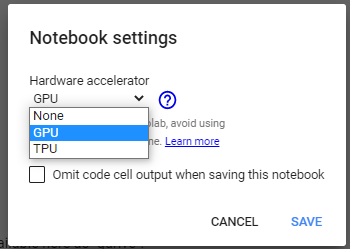

### Mount your google drive

Run this cell to connect your Google Drive to colab:
* Click on the URL.
* Sign in your Google Account.

You will either have to:
* copy the authorisation code and enter it into box below OR
* in the new google colab, you can just click "Allow" and it should connect.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Then click on "Folder" icon on the Left, press the refresh button. Your Google Drive folder should now be available here as "gdrive".


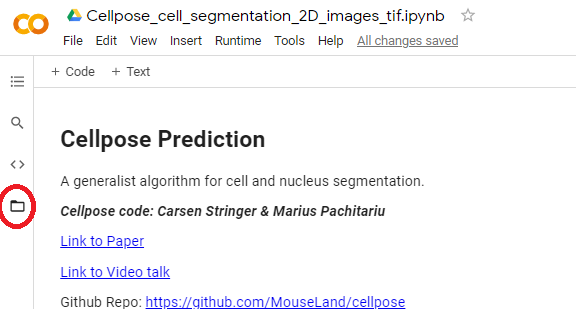

Click on the triangle icon and it will allow you to access whole drive. Navigate to the folder containing your images. Once you are there, click on the three dots on the right of the folder and select "Copy Path"

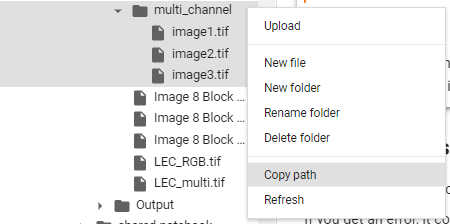

Copy and paste this path in the **dir** string below

### Install Cellpose-SAM


In [ ]:
!pip install git+https://www.github.com/mouseland/cellpose.git

Check GPU and instantiate model - will download weights.

In [9]:
!pip install cellpose[dino]

  Cloning https://github.com/facebookresearch/dinov3.git to /tmp/pip-install-6w90spyn/dinov3_cae44f3faaea435db58a5c7d07cbb755
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/dinov3.git /tmp/pip-install-6w90spyn/dinov3_cae44f3faaea435db58a5c7d07cbb755
  Resolved https://github.com/facebookresearch/dinov3.git to commit 50001c6db58dbca7e7d06a5c5a9f1e078ca29197
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 61.3 MB/s eta 0:00:00
  Created wheel for dinov3: filename=dinov3-0.0.1-py3-none-any.whl size=331019 sha256=40eccd337213c9b0d9dead9e620bfefb2b69f9bb01265e78ad16cad920ee2363
  Stored in directory: /tmp/pip-ephem-wheel-cache-dgc0wtcc/wheels/34/3c/5d

In [10]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

creating new log file
[GUI INFO] : WRITING LOG OUTPUT TO /root/.cellpose/run.log

cellpose version: 	4.2.1.dev1+g778ae2e5d 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.11.0+cu128
2026-06-07 19:35:29,075 [io INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-06-07 19:35:29,078 [io INFO] 
cellpose version: 	4.2.1.dev1+g778ae2e5d 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.11.0+cu128
2026-06-07 19:35:29,739 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-07 19:35:29,741 [core INFO] ** TORCH CUDA version installed and working. **
2026-06-07 19:35:29,746 [core INFO] >>>> using GPU (CUDA)
2026-06-07 19:35:29,750 [models INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpdino" to /root/.cellpose/models/cpdino



100%|██████████| 1.13G/1.13G [00:11<00:00, 110MB/s]


2026-06-07 19:35:46,149 [models INFO] >>>> loading model /root/.cellpose/models/cpdino


Input directory with your images:

In [11]:
# *** change to your google drive folder path ***
dir = "/content/CT_AR/"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".tif"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

6 images in folder:
W0025F0004T0001Z001C1.tif
W0025F0006T0001Z001C1.tif
W0025F0008T0001Z001C1.tif
W0026F0004T0001Z001C1.tif
W0026F0007T0001Z001C1.tif
W0026F0017T0001Z001C1.tif


## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



In [12]:
img = io.imread(files[0])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (2000, 2000). Assuming channel dimension is last with 2000 channels


### Channel Selection:

- Use the dropdowns below to select the _zero-indexed_ channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

- If you have a histological image taken in brightfield, you don't need to adjust the channels.

- If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to `None`. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a thrid stain (described below), you can run segmentation with all channels.

In [16]:
first_channel = '1' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = 'None' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = 'None' # @param ['None', 0, 1, 2, 3, 4, 5]

/usr/local/lib/python3.12/dist-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


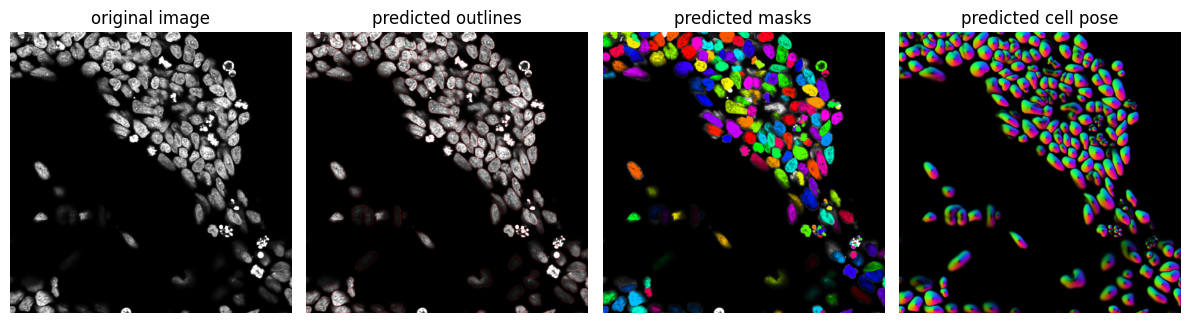

In [23]:
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  # Remove original invalid channel dimension check for 2D images
  # if int(c) > img.shape[-1]:
  #   assert False, 'invalid channel index, must have index greater or equal to the number of channels'
  if c != 'None':
    selected_channels.append(int(c))



# Handle channel selection based on image dimensions
if img.ndim == 2:
    if len(selected_channels) == 0:
        # If no specific channel is selected for a 2D image, treat it as single channel
        img_selected_channels = img[..., np.newaxis]
    elif len(selected_channels) == 1 and selected_channels[0] == 0:
        # If '0' is selected for a 2D image, treat it as single channel
        img_selected_channels = img[..., np.newaxis]
    else:
        # Invalid channel selection for a 2D image
        raise ValueError(f"2D image detected. Invalid channel selection: {selected_channels}. For 2D images, only '0' or 'None' is valid, indicating a single channel.")
elif img.ndim == 3:
    # Ensure all selected channel indices are valid for a 3D image
    for c_idx in selected_channels:
        if c_idx >= img.shape[-1]:
            raise ValueError(f"Invalid channel index {c_idx} for a 3D image with {img.shape[-1]} channels.")

    if len(selected_channels) == 0:
        # If no specific channels are selected for a 3D image, use all channels directly
        img_selected_channels = img
    else:
        # If specific channels are selected for a 3D image
        # Create a new array with the selected channels
        img_selected_channels = np.zeros(img.shape[0:2] + (len(selected_channels),), dtype=img.dtype)
        for idx, channel_in_original in enumerate(selected_channels):
            img_selected_channels[:, :, idx] = img[:, :, channel_in_original]
else:
    # Handle other dimensions if necessary, or raise an error
    raise ValueError(f"Unsupported image dimension: {img.ndim}. Only 2D and 3D images are supported.")


flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

# Reduced batch_size from 32 to 4 to prevent OutOfMemoryError
masks, flows, styles = model.eval(img_selected_channels, batch_size=4, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()

## Run Cellpose-SAM on folder of images

> Add blockquote



if you have many large images, you may want to run them as a loop over images



In [25]:
masks_ext = ".png" if image_ext == ".png" else ".tif"
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)
    masks, flows, styles = model.eval(img, batch_size=4, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)

100%|██████████| 6/6 [06:40<00:00, 66.74s/it]


if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [ ]:
print("loading images")
imgs = [io.imread(files[i]) for i in trange(len(files))]

print("running cellpose-SAM")
masks, flows, styles = model.eval(imgs, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

print("saving masks")
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks[i])

to save your masks for ImageJ, run the following code:

In [ ]:
for i in trange(len(files)):
    f = files[i]
    masks0 = io.imsave(dir / (f.name + "_masks" + masks_ext))
    io.save_rois(masks0, f)